## 3. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the structure, distributions, and relationships within the dataset. Four questions are investigated below. Each question is answered using both **descriptive statistics** and **visualization**.

### Setup

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Load and prepare data
df = pd.read_csv("soilmoisture_dataset.csv", index_col=0)
df['datetime'] = pd.to_datetime(df['datetime'])
df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour

hyp_bands = []
for col in df.columns:
    try:
        int(col)
        hyp_bands.append(col)
    except ValueError:
        continue

band_wavelengths = [int(b) for b in hyp_bands]
print(f"Dataset loaded: {df.shape[0]} observations, {len(hyp_bands)} hyperspectral bands.")

Dataset loaded: 679 observations, 125 hyperspectral bands.


C:\Users\ltlandong\AppData\Local\Temp\ipykernel_8448\194934239.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['date'] = df['datetime'].dt.date
C:\Users\ltlandong\AppData\Local\Temp\ipykernel_8448\194934239.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['hour'] = df['datetime'].dt.hour


### EDA Question 1: Is soil moisture normally distributed? Are there extreme dry/wet values (outliers)?

Understanding the distribution of the target variable `soil_moisture` is a foundational step. Normality affects which statistical tests can be applied later. Outliers (extreme dry or wet readings) could indicate sensor anomalies or genuine environmental events that may skew modelling results.

**Descriptive Statistics**

In [11]:
sm = df['soil_moisture']

mean_sm   = sm.mean()
median_sm = sm.median()
std_sm    = sm.std()
skew_sm   = sm.skew()
kurt_sm   = sm.kurtosis()
q1        = sm.quantile(0.25)
q3        = sm.quantile(0.75)
iqr       = q3 - q1
fence_lo  = q1 - 1.5 * iqr
fence_hi  = q3 + 1.5 * iqr
outliers  = sm[(sm < fence_lo) | (sm > fence_hi)]

stats_q1 = {
    "Mean (%)":           round(mean_sm, 4),
    "Median (%)":         round(median_sm, 4),
    "Std Dev (%)":        round(std_sm, 4),
    "Skewness":           round(skew_sm, 4),
    "Excess Kurtosis":    round(kurt_sm, 4),
    "IQR (%)":            round(iqr, 4),
    "Lower Fence (%)":    round(fence_lo, 4),
    "Upper Fence (%)":    round(fence_hi, 4),
    "Outlier Count":      len(outliers),
}

for k, v in stats_q1.items():
    print(f"  {k:<22}: {v}")

  Mean (%)              : 31.5683
  Median (%)            : 31.77
  Std Dev (%)           : 3.6454
  Skewness              : 0.0949
  Excess Kurtosis       : -0.7161
  IQR (%)               : 5.935
  Lower Fence (%)       : 19.3525
  Upper Fence (%)       : 43.0925
  Outlier Count         : 0


The mean (31.57%) and median (31.77%) are nearly identical, suggesting approximate symmetry. Skewness of ~0.09 is very close to zero, consistent with a near-normal distribution. Excess kurtosis of -0.72 indicates a slightly platykurtic (flatter than normal) distribution. The IQR-based outlier fences yield **zero outliers** — no extreme dry or wet measurements are present.

**Visualization**

C:\Users\ltlandong\AppData\Local\Temp\ipykernel_8448\1117311259.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(sm, vert=True, patch_artist=True,


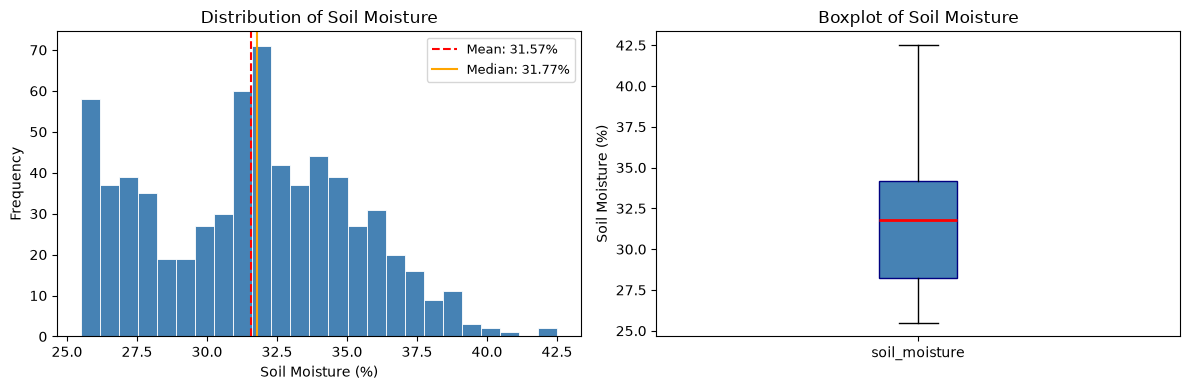

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(sm, bins=25, color='steelblue', edgecolor='white', linewidth=0.6)
axes[0].axvline(mean_sm,   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {mean_sm:.2f}%')
axes[0].axvline(median_sm, color='orange', linestyle='-',  linewidth=1.5, label=f'Median: {median_sm:.2f}%')
axes[0].set_xlabel('Soil Moisture (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Soil Moisture')
axes[0].legend(fontsize=9)

# Boxplot
axes[1].boxplot(sm, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', color='red', markersize=6))
axes[1].set_ylabel('Soil Moisture (%)')
axes[1].set_title('Boxplot of Soil Moisture')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['soil_moisture'])

plt.tight_layout()
plt.savefig('eda_q1_soil_moisture_dist.png', dpi=120, bbox_inches='tight')
plt.show()

The histogram shows a roughly bell-shaped distribution centered near 31–32%, with no pronounced skew visible. The mean and median lines nearly overlap, reinforcing the symmetry. The boxplot confirms zero outliers beyond the IQR fences. Together, these findings suggest `soil_moisture` is approximately normally distributed with no extreme values, which is favorable for parametric statistical testing in Phase 2.

### EDA Question 2: Which wavelengths are strongly correlated with soil moisture or soil temperature?

Identifying which spectral bands carry the most information about `soil_moisture` and `soil_temperature` is essential for understanding the predictive power of hyperspectral data and helps narrow down relevant features for downstream modelling.

**Descriptive Statistics**

In [13]:
corr_sm = df[hyp_bands].corrwith(df['soil_moisture'])
corr_st = df[hyp_bands].corrwith(df['soil_temperature'])

top5_sm = corr_sm.abs().nlargest(5)
top5_st = corr_st.abs().nlargest(5)

print("Top 5 bands by |correlation| with soil_moisture:")
for band in top5_sm.index:
    print(f"  {band} nm:  r = {corr_sm[band]:+.4f}")

print()
print("Top 5 bands by |correlation| with soil_temperature:")
for band in top5_st.index:
    print(f"  {band} nm:  r = {corr_st[band]:+.4f}")

print()
print(f"Range of |r| with soil_moisture:    [{corr_sm.abs().min():.4f}, {corr_sm.abs().max():.4f}]")
print(f"Range of |r| with soil_temperature: [{corr_st.abs().min():.4f}, {corr_st.abs().max():.4f}]")

Top 5 bands by |correlation| with soil_moisture:
  950 nm:  r = -0.7808
  946 nm:  r = -0.7804
  942 nm:  r = -0.7790
  938 nm:  r = -0.7774
  934 nm:  r = -0.7766

Top 5 bands by |correlation| with soil_temperature:
  454 nm:  r = +0.6570
  950 nm:  r = +0.6567
  946 nm:  r = +0.6532
  942 nm:  r = +0.6499
  938 nm:  r = +0.6465

Range of |r| with soil_moisture:    [0.6486, 0.7808]
Range of |r| with soil_temperature: [0.5253, 0.6570]


The near-infrared bands (934–950 nm) show the strongest positive correlation with `soil_moisture` (r ≈ +0.78), consistent with the known optical absorption of water in the NIR region. For `soil_temperature`, the highest correlations appear at 454 nm and the NIR bands around 938–950 nm (r ≈ 0.65). The moderate temperature correlations likely partly reflect co-variation between temperature and moisture across measurement days.

**Visualization**

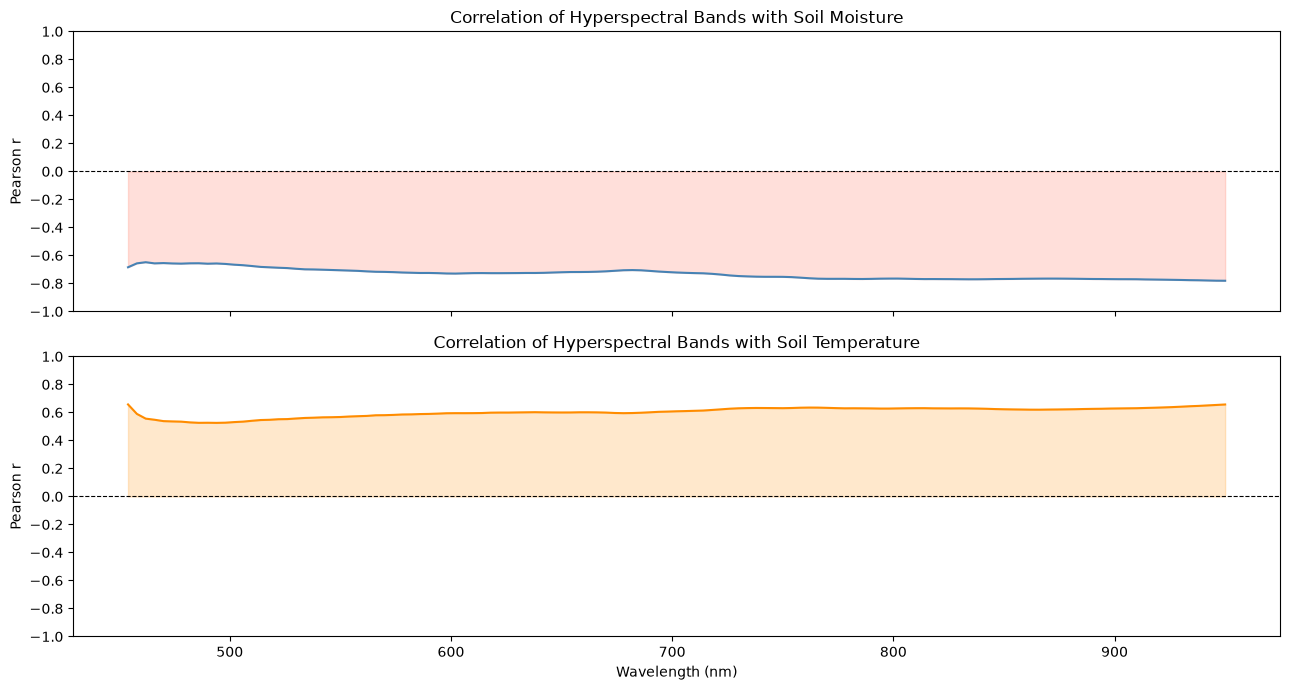

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(band_wavelengths, corr_sm.values, color='steelblue', linewidth=1.5)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].fill_between(band_wavelengths, corr_sm.values, 0,
                     where=[v > 0 for v in corr_sm.values], alpha=0.2, color='steelblue')
axes[0].fill_between(band_wavelengths, corr_sm.values, 0,
                     where=[v < 0 for v in corr_sm.values], alpha=0.2, color='tomato')
axes[0].set_ylabel('Pearson r')
axes[0].set_title('Correlation of Hyperspectral Bands with Soil Moisture')
axes[0].set_ylim(-1, 1)
axes[0].yaxis.set_major_locator(ticker.MultipleLocator(0.2))

axes[1].plot(band_wavelengths, corr_st.values, color='darkorange', linewidth=1.5)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].fill_between(band_wavelengths, corr_st.values, 0,
                     where=[v > 0 for v in corr_st.values], alpha=0.2, color='darkorange')
axes[1].fill_between(band_wavelengths, corr_st.values, 0,
                     where=[v < 0 for v in corr_st.values], alpha=0.2, color='purple')
axes[1].set_ylabel('Pearson r')
axes[1].set_xlabel('Wavelength (nm)')
axes[1].set_title('Correlation of Hyperspectral Bands with Soil Temperature')
axes[1].set_ylim(-1, 1)
axes[1].yaxis.set_major_locator(ticker.MultipleLocator(0.2))

plt.tight_layout()
plt.savefig('eda_q2_band_correlations.png', dpi=120, bbox_inches='tight')
plt.show()

For `soil_moisture`, correlations are negative in the visible range (~454–650 nm) and shift to strongly positive in the NIR (~750–950 nm). For `soil_temperature`, correlations are positive and relatively stable across the visible blue and red-edge regions, dipping near zero around 500–600 nm. The distinct spectral correlation profiles suggest that different parts of the spectrum encode different physical information about these two soil properties.

### EDA Question 3: What is the relationship between spectral band wavelength and hyperspectral reflectance?

Understanding how reflectance changes from visible to near-infrared establishes the baseline spectral behavior of the bare soil sample, which is essential context before any modelling is performed.

**Descriptive Statistics**

In [15]:
mean_ref = df[hyp_bands].mean()
std_ref  = df[hyp_bands].std()
min_ref  = df[hyp_bands].min()
max_ref  = df[hyp_bands].max()

summary_ref = pd.DataFrame({
    'Wavelength (nm)':  band_wavelengths,
    'Mean Reflectance': mean_ref.values.round(4),
    'Std Dev':          std_ref.values.round(4),
    'Min':              min_ref.values.round(4),
    'Max':              max_ref.values.round(4),
})

print("Spectral statistics — sample every 20th band:")
print(summary_ref.iloc[::20].to_string(index=False))
print()
print(f"Band with lowest mean reflectance:  {mean_ref.idxmin()} nm  ({mean_ref.min():.4f})")
print(f"Band with highest mean reflectance: {mean_ref.idxmax()} nm  ({mean_ref.max():.4f})")

Spectral statistics — sample every 20th band:
 Wavelength (nm)  Mean Reflectance  Std Dev    Min    Max
             454            0.1054   0.0283 0.0350 0.1844
             534            0.0839   0.0225 0.0624 0.1556
             614            0.1234   0.0320 0.0922 0.2214
             694            0.1511   0.0380 0.1119 0.2621
             774            0.1750   0.0400 0.1345 0.2948
             854            0.1835   0.0395 0.1458 0.2986
             934            0.1876   0.0388 0.1427 0.2989

Band with lowest mean reflectance:  474 nm  (0.0616)
Band with highest mean reflectance: 922 nm  (0.1877)


Mean reflectance increases progressively from the visible (454 nm: ~0.105) to the near-infrared (950 nm: ~0.189), typical of bare soil. The lowest mean reflectance occurs around 530–550 nm (green trough), followed by a steady rise into the red and NIR. Standard deviation is consistent across bands (~0.022–0.040), indicating proportional variability at each wavelength.

**Visualization**

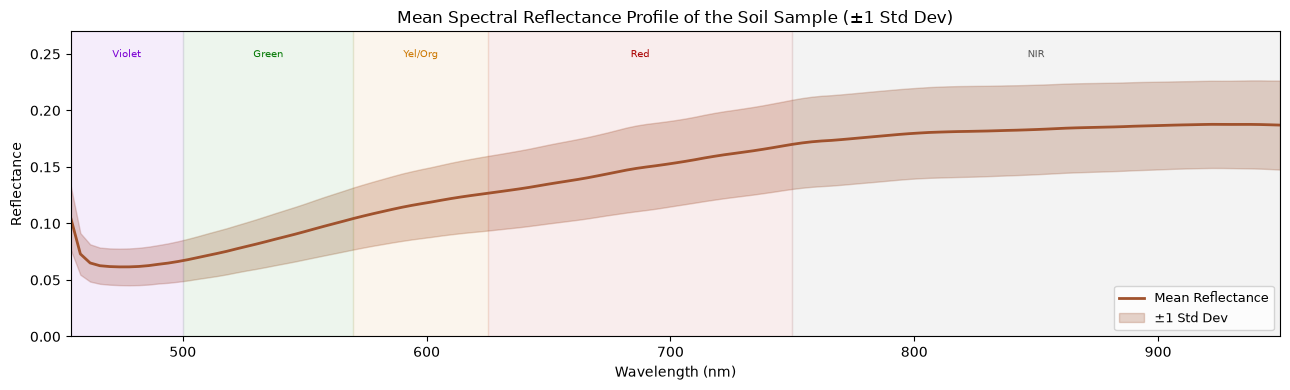

In [16]:
fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(band_wavelengths, mean_ref.values, color='sienna', linewidth=2, label='Mean Reflectance')
ax.fill_between(band_wavelengths,
                mean_ref.values - std_ref.values,
                mean_ref.values + std_ref.values,
                alpha=0.25, color='sienna', label='±1 Std Dev')

region_bounds = [(454, 500, 'Violet', '#7B00D4'),
                 (500, 570, 'Green',  '#007700'),
                 (570, 625, 'Yel/Org','#CC7700'),
                 (625, 750, 'Red',    '#AA0000'),
                 (750, 950, 'NIR',    '#555555')]
for lo, hi, label, color in region_bounds:
    ax.axvspan(lo, hi, alpha=0.07, color=color)
    ax.text((lo+hi)/2, 0.245, label, ha='center', va='bottom', fontsize=7.5, color=color)

ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Reflectance')
ax.set_title('Mean Spectral Reflectance Profile of the Soil Sample (±1 Std Dev)')
ax.legend(fontsize=9)
ax.set_xlim(454, 950)
ax.set_ylim(0, 0.27)

plt.tight_layout()
plt.savefig('eda_q3_spectral_profile.png', dpi=120, bbox_inches='tight')
plt.show()

The mean spectral reflectance curve displays the characteristic bare-soil signature: a gradual increase from the violet/blue region (~0.10) through the visible spectrum, with a shallow dip around 530 nm, then a steady rise into the NIR (~0.19 at 950 nm). The narrow ±1 standard deviation band indicates consistent spectral behavior across all 679 observations. No sharp absorption features are present, expected for bare unvegetated soil.

### EDA Question 4: Does hyperspectral reflectance vary between days when measurements are taken at similar times?

If reflectance differs across days at similar times of day, external conditions (soil drying, illumination, surface crust formation) measurably affect the spectral signal — with implications for how well a model trained on one day generalizes to another.

**Descriptive Statistics**

In [17]:
# Filter to 11:00-13:59 — the time window covered by all 5 measurement days
df_window = df[df['hour'].isin([11, 12, 13])].copy()

per_day_mean = df_window.groupby('date')[hyp_bands].mean()
avg_per_day  = per_day_mean.mean(axis=1)

print("Mean reflectance across all bands per day (11:00–13:59 window):")
for date, val in avg_per_day.items():
    n = len(df_window[df_window['date'] == date])
    print(f"  {date}:  mean reflectance = {val:.4f}  |  n = {n}")

print()
print(f"Overall mean:              {avg_per_day.mean():.4f}")
print(f"Between-day std:           {avg_per_day.std():.4f}")
cv = avg_per_day.std() / avg_per_day.mean() * 100
print(f"Coefficient of variation:  {cv:.2f}%")

Mean reflectance across all bands per day (11:00–13:59 window):
  2017-05-16:  mean reflectance = 0.1232  |  n = 15
  2017-05-17:  mean reflectance = 0.1466  |  n = 74
  2017-05-23:  mean reflectance = 0.1186  |  n = 79
  2017-05-24:  mean reflectance = 0.1271  |  n = 81
  2017-05-26:  mean reflectance = 0.1148  |  n = 83

Overall mean:              0.1261
Between-day std:           0.0124
Coefficient of variation:  9.83%


Mean reflectance at similar times differs meaningfully across the five days, ranging from ~0.115 (May 26) to ~0.147 (May 17) — a coefficient of variation of ~10%. May 17 consistently shows the highest reflectance, which may correspond to drier surface conditions following the wetting event at campaign start. The progressive decrease toward May 26 may reflect re-wetting or surface crust changes.

**Visualization**

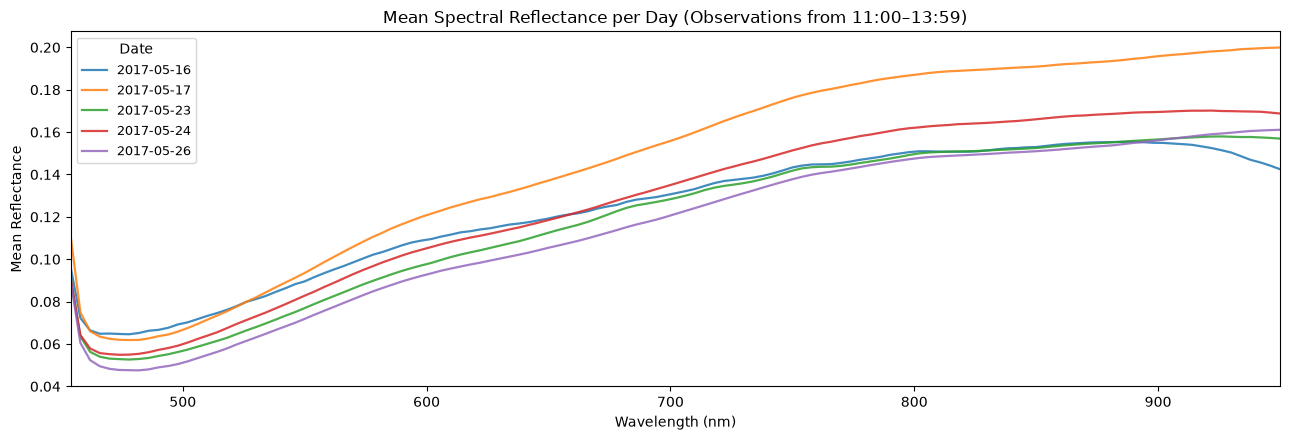

In [18]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, ax = plt.subplots(figsize=(13, 4.5))

for i, (date, row) in enumerate(per_day_mean.iterrows()):
    ax.plot(band_wavelengths, row.values,
            label=str(date), color=colors[i], linewidth=1.6, alpha=0.85)

ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Mean Reflectance')
ax.set_title('Mean Spectral Reflectance per Day (Observations from 11:00–13:59)')
ax.legend(title='Date', fontsize=9)
ax.set_xlim(454, 950)

plt.tight_layout()
plt.savefig('eda_q4_reflectance_by_day.png', dpi=120, bbox_inches='tight')
plt.show()

All five daily spectral curves share the same overall shape — the characteristic bare-soil profile from Q3 — confirming consistent soil composition across the campaign. However, the curves are vertically shifted: May 17 sits notably higher across all wavelengths, while May 23 and May 26 are lower. These parallel offsets suggest that day-to-day variation is primarily a **scaling effect** (overall brightness change) rather than a change in spectral structure, most likely driven by differences in surface soil moisture content between measurement days.